<a href="https://colab.research.google.com/github/Tathaj17/IITGenAI_Assighnment1/blob/master/Classification_Models_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [1]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [14]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
### CODE HERE ###
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df['target'])


0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64


In [19]:
# Separate features and target, remap so malignant = 1
### CODE HERE ###
X = df.drop('target', axis=1)
y = df['target'].map({0: 1, 1: 0})
print(y)


0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: target, Length: 569, dtype: int64


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [20]:
# Display first 5 rows
### CODE HERE ###
df.head(5)



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [28]:
# Check shape, data types, and missing values
### CODE HERE ###
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())



(569, 31)
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symm

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [29]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
### CODE HERE ###
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


target
0    357
1    212
Name: count, dtype: int64


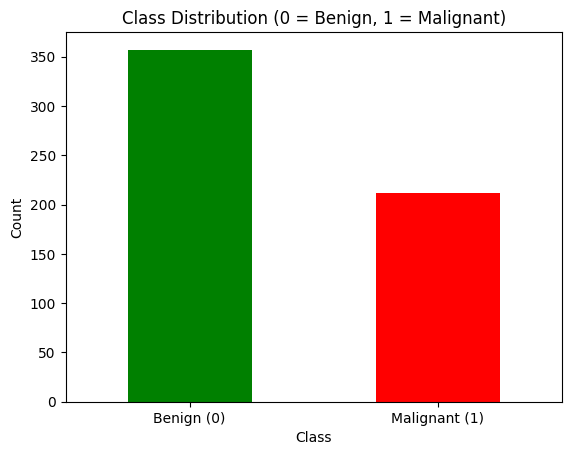

In [32]:
# Class distribution after remapping
### CODE HERE ###
# Class distribution after remapping
print(y.value_counts())

y.value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (0 = Benign, 1 = Malignant)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Benign (0)', 'Malignant (1)'], rotation=0)
plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


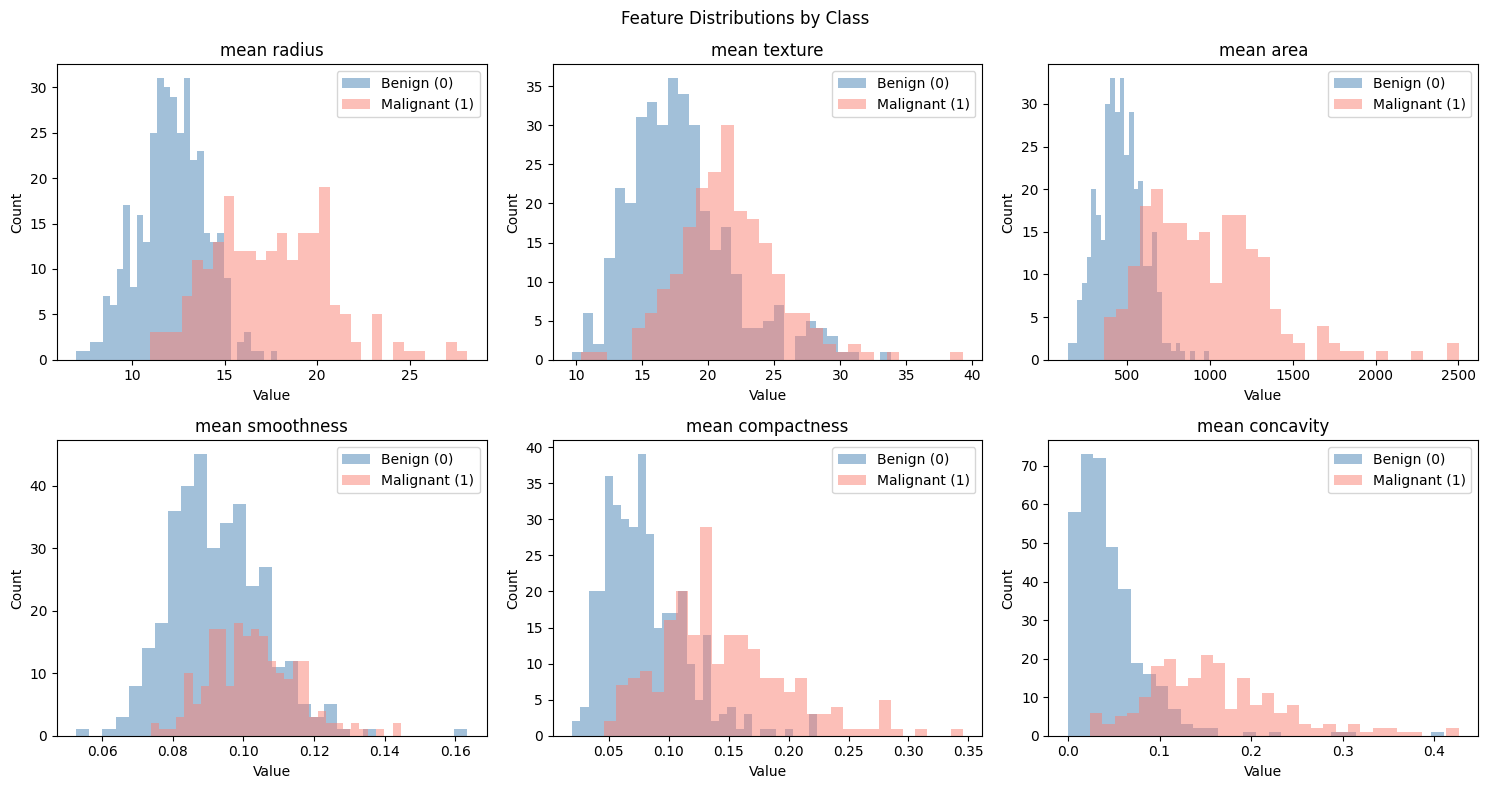

In [33]:
# Feature distributions for 6 selected features, coloured by class
### CODE HERE ###
# Feature distributions for 6 selected features, coloured by class
features = ['mean radius', 'mean texture', 'mean area',
            'mean smoothness', 'mean compactness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(X[y == 0][feature], bins=30, alpha=0.5,
                 color='steelblue', label='Benign (0)')
    axes[i].hist(X[y == 1][feature], bins=30, alpha=0.5,
                 color='salmon', label='Malignant (1)')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions by Class')
plt.tight_layout()
plt.show()

### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. The dataset is moderately imbalanced — there are 357 benign and 212 malignant cases. If imbalance is severe, the model tends to favour the majority class (benign) because predicting it more often gives higher overall accuracy. This means the model might miss many actual cancer cases, which is dangerous in a medical setting.

2. No, the features have very different scales — for example mean radius is ~14 while mean area is ~654 and mean fractal dimension is ~0.06. Models like KNN and SVM are distance-based, meaning they calculate how far apart data points are. If one feature has much larger values, it will dominate the distance calculation and the model will effectively ignore the smaller-scaled features, giving wrong results.

3. In cancer detection, the cost of a false negative (telling a patient they don't have cancer when they actually do) is far more dangerous than a false positive. Accuracy treats all mistakes equally, but recall specifically measures how many actual malignant cases the model correctly caught. So recall directly tells us how good the model is at not missing cancer, which is the most critical goal here.

4. If you fit the scaler on the full dataset, the mean and standard deviation used for scaling will be calculated using test data as well. This means the training process has indirectly seen information from the test set — specifically its distribution and range — which is called data leakage. As a result your model's performance on the test set will look better than it really is, giving you a falsely optimistic evaluation.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [35]:
# Missing value audit
### CODE HERE ###
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# If any missing values exist, fill with median
if missing.sum() > 0:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print("Missing values filled with median.")
else:
    print("No missing values found. No imputation needed.")


Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total missing values: 0
No missing values found. No imputati

### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [36]:
# Stratified train-test split
### CODE HERE ###
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"\nClass distribution in y_train:\n{y_train.value_counts()}")
print(f"\nClass distribution in y_test:\n{y_test.value_counts()}")



Training set size: (398, 30)
Test set size:     (171, 30)

Class distribution in y_train:
target
0    250
1    148
Name: count, dtype: int64

Class distribution in y_test:
target
0    107
1     64
Name: count, dtype: int64


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [38]:
# Feature scaling: fit on train only, transform both
### CODE HERE ###
# Feature scaling: fit on train only, transform both
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [39]:
# Confirm prepared data
### CODE HERE ###
# Confirm shapes
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

# Verify class distribution
print(f"\nClass distribution in y_train:\n{y_train.value_counts()}")
print(f"\nClass distribution in y_test:\n{y_test.value_counts()}")

X_train_scaled shape: (398, 30)
X_test_scaled shape:  (171, 30)
y_train shape: (398,)
y_test shape:  (171,)

Class distribution in y_train:
target
0    250
1    148
Name: count, dtype: int64

Class distribution in y_test:
target
0    107
1     64
Name: count, dtype: int64


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [42]:
# Helper function. Use this to evaluate all models consistently.
### CODE HERE ###
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"=== {model_name} ===")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    return y_pred

## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [44]:
# Logistic Regression with GridSearchCV
### CODE HERE ###
# Logistic Regression with GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV recall:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_



Best parameters: {'C': 10}
Best CV recall: 0.9388505747126438


In [45]:
# Evaluate LR on test set
### CODE HERE ###
# Evaluate LR on test set
y_pred_lr = evaluate_model(best_lr, X_test_scaled, y_test, "Logistic Regression")


=== Logistic Regression ===
Accuracy:  0.9708
Precision: 0.9836
Recall:    0.9375
F1 Score:  0.9600

Confusion Matrix:
[[106   1]
 [  4  60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [47]:
# KNN with GridSearchCV
### CODE HERE ###
# KNN with GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best parameters:", grid_knn.best_params_)
print("Best CV recall:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_



Best parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best CV recall: 0.925287356321839


In [48]:
# Evaluate KNN on test set
### CODE HERE ###
# Evaluate KNN on test set
y_pred_knn = evaluate_model(best_knn, X_test_scaled, y_test, "KNN")


=== KNN ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1 Score:  0.9508

Confusion Matrix:
[[107   0]
 [  6  58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [49]:
# Decision Tree with GridSearchCV
### CODE HERE ###
# Decision Tree with GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)

print("Best parameters:", grid_dt.best_params_)
print("Best CV recall:", grid_dt.best_score_)

best_dt = grid_dt.best_estimator_

# Evaluate Decision Tree on test set
y_pred_dt = evaluate_model(best_dt, X_test_scaled, y_test, "Decision Tree")


Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV recall: 0.9319540229885057
=== Decision Tree ===
Accuracy:  0.9064
Precision: 0.9000
Recall:    0.8438
F1 Score:  0.8710

Confusion Matrix:
[[101   6]
 [ 10  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       107
           1       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



In [50]:
# Evaluate Decision Tree on test set
### CODE HERE ###
# Evaluate Decision Tree on test set
y_pred_dt = evaluate_model(best_dt, X_test_scaled, y_test, "Decision Tree")


=== Decision Tree ===
Accuracy:  0.9064
Precision: 0.9000
Recall:    0.8438
F1 Score:  0.8710

Confusion Matrix:
[[101   6]
 [ 10  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       107
           1       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [51]:
# SVM with GridSearchCV
### CODE HERE ###
# SVM with GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=42, probability=True),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best parameters:", grid_svm.best_params_)
print("Best CV recall:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV recall: 0.9519540229885057


In [52]:
# Evaluate SVM on test set
### CODE HERE ###
# Evaluate SVM on test set
y_pred_svm = evaluate_model(best_svm, X_test_scaled, y_test, "SVM")


=== SVM ===
Accuracy:  0.9825
Precision: 0.9841
Recall:    0.9688
F1 Score:  0.9764

Confusion Matrix:
[[106   1]
 [  2  62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       107
           1       0.98      0.97      0.98        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [54]:
# Comparison table for all 4 models
### CODE HERE ###
# Comparison table for all 4 models
def get_metrics(model_name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'False Negatives': cm[1][0]
    }

results = [
    get_metrics("Logistic Regression", y_test, y_pred_lr),
    get_metrics("KNN",                 y_test, y_pred_knn),
    get_metrics("Decision Tree",       y_test, y_pred_dt),
    get_metrics("SVM",                 y_test, y_pred_svm)
]

comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df = comparison_df.round(4)
print(comparison_df)


                     Accuracy  Recall  Precision  F1 Score  False Negatives
Model                                                                      
Logistic Regression    0.9708  0.9375     0.9836    0.9600                4
KNN                    0.9649  0.9062     1.0000    0.9508                6
Decision Tree          0.9064  0.8438     0.9000    0.8710               10
SVM                    0.9825  0.9688     0.9841    0.9764                2


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


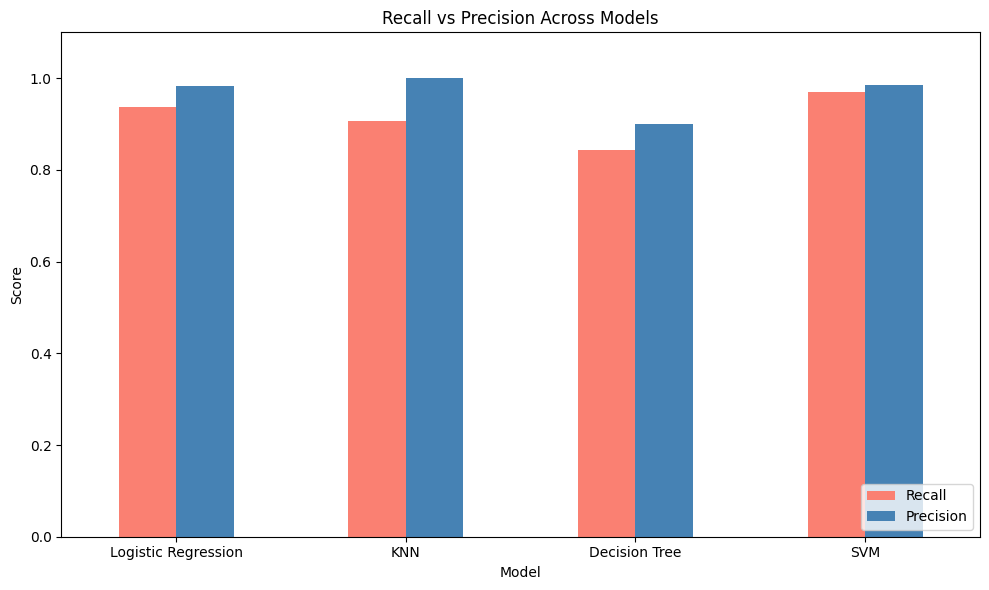

In [55]:
# Grouped bar chart: Recall and Precision
### CODE HERE ###
# Grouped bar chart: Recall and Precision
comparison_df[['Recall', 'Precision']].plot(kind='bar', figsize=(10, 6), color=['salmon', 'steelblue'])

plt.title('Recall vs Precision Across Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [57]:
# Cross-validation stability for all 4 models
### CODE HERE ###
# Cross-validation stability for all 4 models
models = {
    "Logistic Regression": best_lr,
    "KNN":                 best_knn,
    "Decision Tree":       best_dt,
    "SVM":                 best_svm
}

for name, model in models.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='recall', n_jobs=-1)
    print(f"{name}")
    print(f"  Recall per fold: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f}  |  Std: {scores.std():.4f}\n")


Logistic Regression
  Recall per fold: [0.9667 0.9667 0.9667 0.931  0.931 ]
  Mean: 0.9524  |  Std: 0.0175

KNN
  Recall per fold: [0.9333 0.9667 0.9667 0.8276 0.931 ]
  Mean: 0.9251  |  Std: 0.0511

Decision Tree
  Recall per fold: [0.9333 0.7667 0.9667 0.8276 0.8966]
  Mean: 0.8782  |  Std: 0.0724

SVM
  Recall per fold: [0.9667 0.9667 0.9667 0.8966 0.9655]
  Mean: 0.9524  |  Std: 0.0279



### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


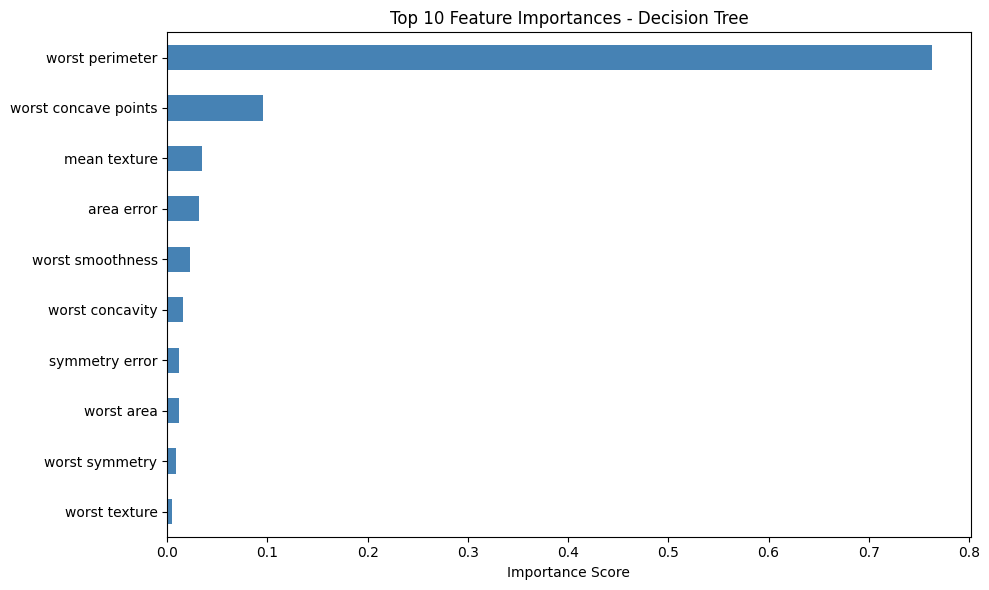

In [58]:
# Feature importance from Decision Tree
### CODE HERE ###
# Feature importance from Decision Tree
importances = pd.Series(best_dt.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

top10.sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


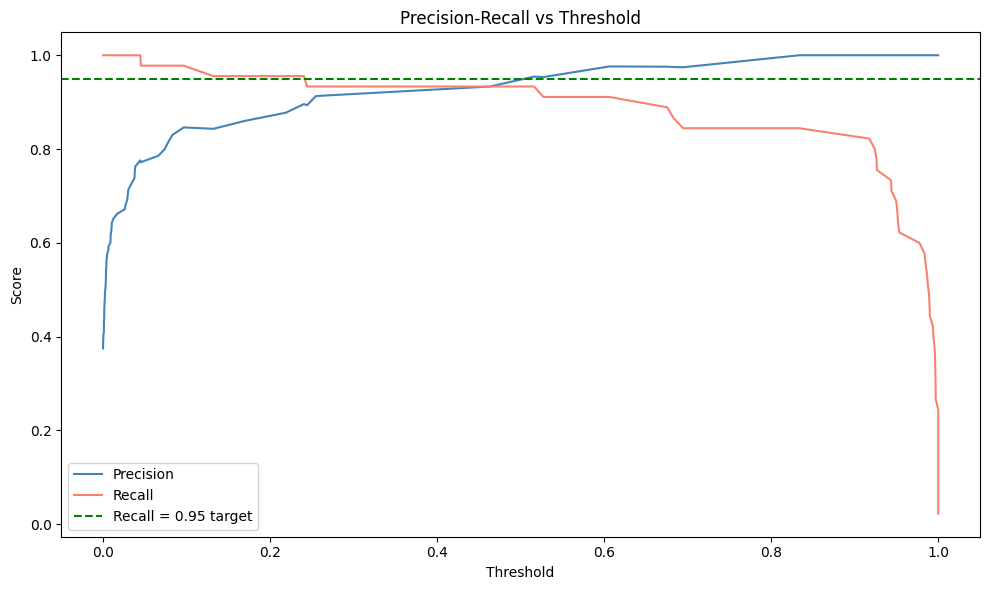

Best threshold for recall >= 0.95: 0.2408


In [59]:
# Step 1: Create inner split from training data
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

# Step 2: Retrain best model (SVM) on inner training set
best_svm.fit(X_train_inner, y_train_inner)

# Step 3: Get predicted probabilities on validation set
y_proba = best_svm.predict_proba(X_val)[:, 1]

# Step 4: Plot precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='salmon')
plt.axhline(y=0.95, color='green', linestyle='--', label='Recall = 0.95 target')
plt.title('Precision-Recall vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Find threshold where recall >= 0.95
target_recall = 0.95
valid_thresholds = thresholds[recalls[:-1] >= target_recall]

if len(valid_thresholds) > 0:
    best_threshold = valid_thresholds[-1]  # highest threshold still achieving recall >= 0.95
    print(f"Best threshold for recall >= 0.95: {best_threshold:.4f}")
else:
    best_threshold = 0.5
    print("No threshold found for recall >= 0.95, using default 0.5")

### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [61]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
### CODE HERE ###
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = pd.Series(wine_data.target)

print(f"Shape: {X_wine.shape}")
print(f"\nClass distribution:\n{y_wine.value_counts().sort_index()}")
print(f"\nFirst 5 rows:\n{X_wine.head()}")


Shape: (178, 13)

Class distribution:
0    59
1    71
2    48
Name: count, dtype: int64

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39    

## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [62]:
# Inspect the wine dataset
print(f"Shape: {X_wine.shape}")
print(f"\nFirst 5 rows:\n{X_wine.head()}")
print(f"\nData types:\n{X_wine.dtypes}")
print(f"\nMissing values:\n{X_wine.isnull().sum()}")


Shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wine

### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


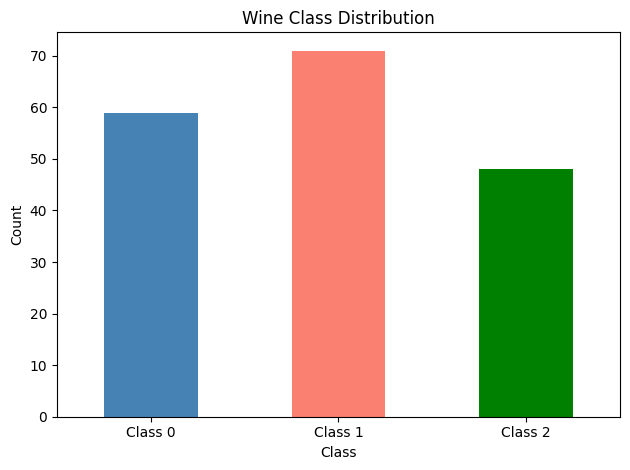

In [63]:
# Wine class distribution
### CODE HERE ###
# Wine class distribution
y_wine.value_counts().sort_index().plot(kind='bar', color=['steelblue', 'salmon', 'green'])
plt.title('Wine Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Class 0', 'Class 1', 'Class 2'], rotation=0)
plt.tight_layout()
plt.show()


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

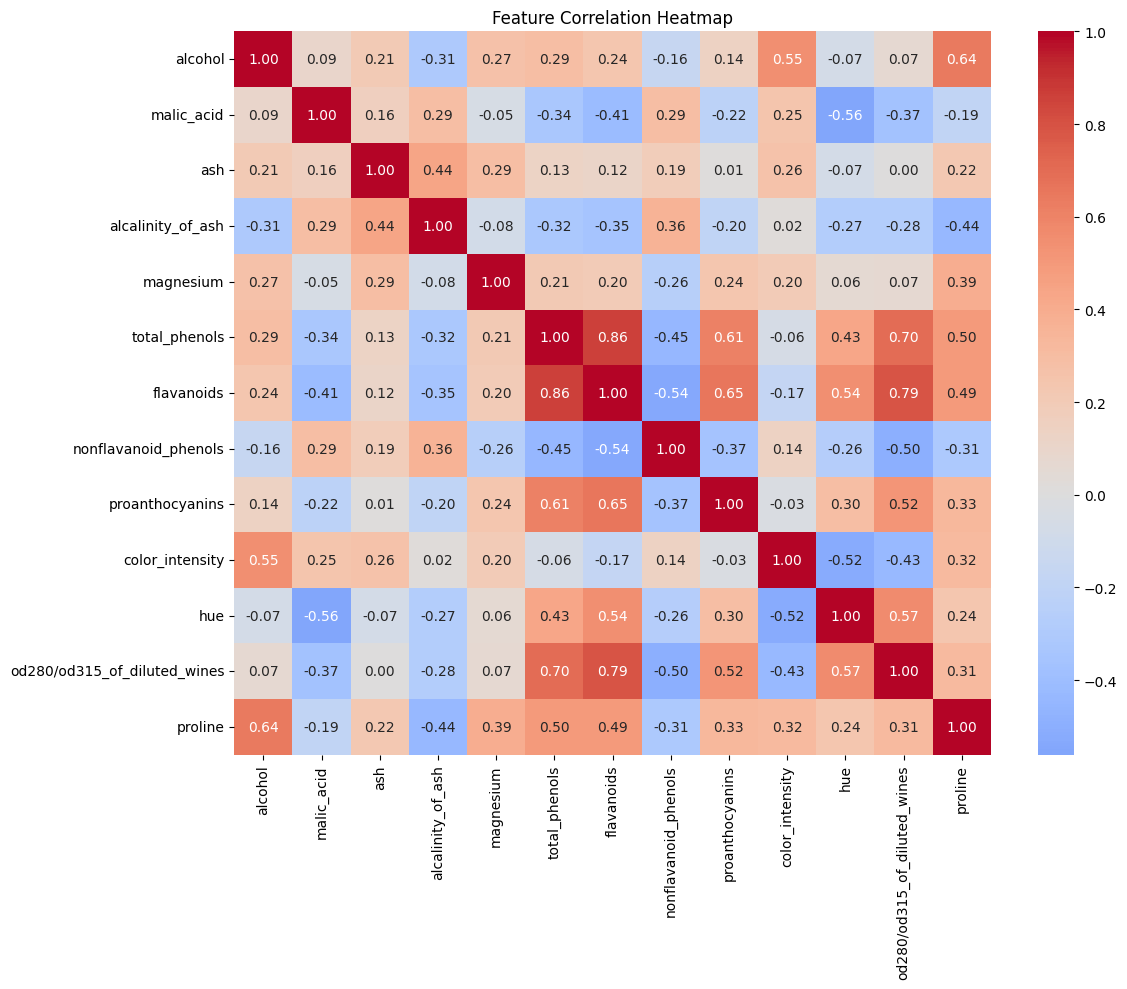

In [65]:
# Summary statistics
print(X_wine.describe())

# Correlation heatmap
import seaborn as sns

# Correlation heatmap
### CODE HERE ###
plt.figure(figsize=(12, 10))
sns.heatmap(X_wine.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [68]:
# Stratified train-test split
### CODE HERE ###
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine,
    test_size=0.3,
    random_state=42,
    stratify=y_wine
)


In [69]:
# Scale features: fit on train, transform both
### CODE HERE ###
scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

print(f"Training set shape: {X_train_w_scaled.shape}")
print(f"Test set shape:     {X_test_w_scaled.shape}")


Training set shape: (124, 13)
Test set shape:     (54, 13)


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [70]:
# Verify preparation
### CODE HERE ###
print(f"X_train shape: {X_train_w_scaled.shape}")
print(f"X_test shape:  {X_test_w_scaled.shape}")
print(f"y_train shape: {y_train_w.shape}")
print(f"y_test shape:  {y_test_w.shape}")


print(f"\nClass distribution in y_train:\n{y_train_w.value_counts().sort_index()}")
print(f"\nClass distribution in y_test:\n{y_test_w.value_counts().sort_index()}")

X_train shape: (124, 13)
X_test shape:  (54, 13)
y_train shape: (124,)
y_test shape:  (54,)

Class distribution in y_train:
0    41
1    50
2    33
Name: count, dtype: int64

Class distribution in y_test:
0    18
1    21
2    15
Name: count, dtype: int64


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [74]:

def evaluate_model_multiclass(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"=== {model_name} ===")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1 Macro:  {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    return y_pred
y_pred_lr_w = evaluate_model_multiclass(best_lr_w, X_test_w_scaled, y_test_w, "Logistic Regression (Wine)")


=== Logistic Regression (Wine) ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Macro:  1.0000

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [75]:
# KNN for Wine
### CODE HERE ###

# KNN for Wine
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

grid_knn_w = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_knn_w.fit(X_train_w_scaled, y_train_w)

print("Best parameters:", grid_knn_w.best_params_)
print("Best CV f1_macro:", grid_knn_w.best_score_)

best_knn_w = grid_knn_w.best_estimator_

y_pred_knn_w = evaluate_model_multiclass(best_knn_w, X_test_w_scaled, y_test_w, "KNN (Wine)")


Best parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best CV f1_macro: 0.9775988992088063
=== KNN (Wine) ===
Accuracy:  0.9630
Precision: 0.9608
Recall:    0.9683
F1 Macro:  0.9625

Confusion Matrix:
[[18  0  0]
 [ 0 19  2]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.90      0.95        21
           2       0.88      1.00      0.94        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [76]:
# Decision Tree for Wine
### CODE HERE ###
# Decision Tree for Wine
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt_w = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_dt_w.fit(X_train_w_scaled, y_train_w)

print("Best parameters:", grid_dt_w.best_params_)
print("Best CV f1_macro:", grid_dt_w.best_score_)

best_dt_w = grid_dt_w.best_estimator_

y_pred_dt_w = evaluate_model_multiclass(best_dt_w, X_test_w_scaled, y_test_w, "Decision Tree (Wine)")


Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV f1_macro: 0.8799972347340768
=== Decision Tree (Wine) ===
Accuracy:  0.9630
Precision: 0.9710
Recall:    0.9593
F1 Macro:  0.9638

Confusion Matrix:
[[17  1  0]
 [ 0 21  0]
 [ 0  1 14]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [77]:
# SVM for Wine
### CODE HERE ###
# SVM for Wine
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm_w = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_svm_w.fit(X_train_w_scaled, y_train_w)

print("Best parameters:", grid_svm_w.best_params_)
print("Best CV f1_macro:", grid_svm_w.best_score_)

best_svm_w = grid_svm_w.best_estimator_

y_pred_svm_w = evaluate_model_multiclass(best_svm_w, X_test_w_scaled, y_test_w, "SVM (Wine)")


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV f1_macro: 0.992046783625731
=== SVM (Wine) ===
Accuracy:  0.9815
Precision: 0.9848
Recall:    0.9778
F1 Macro:  0.9808

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [78]:
# MLP for Wine
### CODE HERE ###
# MLP for Wine
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_mlp_w = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, random_state=42, early_stopping=True),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_mlp_w.fit(X_train_w_scaled, y_train_w)

print("Best parameters:", grid_mlp_w.best_params_)
print("Best CV f1_macro:", grid_mlp_w.best_score_)

best_mlp_w = grid_mlp_w.best_estimator_

y_pred_mlp_w = evaluate_model_multiclass(best_mlp_w, X_test_w_scaled, y_test_w, "MLP (Wine)")


Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
Best CV f1_macro: 0.9136279016646496
=== MLP (Wine) ===
Accuracy:  0.8519
Precision: 0.8720
Recall:    0.8730
F1 Macro:  0.8506

Confusion Matrix:
[[18  0  0]
 [ 5 13  3]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        18
           1       1.00      0.62      0.76        21
           2       0.83      1.00      0.91        15

    accuracy                           0.85        54
   macro avg       0.87      0.87      0.85        54
weighted avg       0.88      0.85      0.84        54



In [79]:
# Evaluate MLP on test set
### CODE HERE ###
# Evaluate MLP on test set
y_pred_mlp_w = evaluate_model_multiclass(best_mlp_w, X_test_w_scaled, y_test_w, "MLP (Wine)")


=== MLP (Wine) ===
Accuracy:  0.8519
Precision: 0.8720
Recall:    0.8730
F1 Macro:  0.8506

Confusion Matrix:
[[18  0  0]
 [ 5 13  3]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        18
           1       1.00      0.62      0.76        21
           2       0.83      1.00      0.91        15

    accuracy                           0.85        54
   macro avg       0.87      0.87      0.85        54
weighted avg       0.88      0.85      0.84        54



### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [81]:
# Comparison table for all 5 wine models
### CODE HERE ###
def get_metrics_multiclass(model_name, y_test, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro Precision': precision_score(y_test, y_pred, average='macro'),
        'Macro Recall': recall_score(y_test, y_pred, average='macro'),
        'Macro F1': f1_score(y_test, y_pred, average='macro')
    }

results_w = [
    get_metrics_multiclass("Logistic Regression", y_test_w, y_pred_lr_w),
    get_metrics_multiclass("KNN",                 y_test_w, y_pred_knn_w),
    get_metrics_multiclass("Decision Tree",       y_test_w, y_pred_dt_w),
    get_metrics_multiclass("SVM",                 y_test_w, y_pred_svm_w),
    get_metrics_multiclass("MLP",                 y_test_w, y_pred_mlp_w)
]

comparison_df_w = pd.DataFrame(results_w).set_index('Model')
comparison_df_w = comparison_df_w.round(4)
print(comparison_df_w)



                     Accuracy  Macro Precision  Macro Recall  Macro F1
Model                                                                 
Logistic Regression    1.0000           1.0000        1.0000    1.0000
KNN                    0.9630           0.9608        0.9683    0.9625
Decision Tree          0.9630           0.9710        0.9593    0.9638
SVM                    0.9815           0.9848        0.9778    0.9808
MLP                    0.8519           0.8720        0.8730    0.8506


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


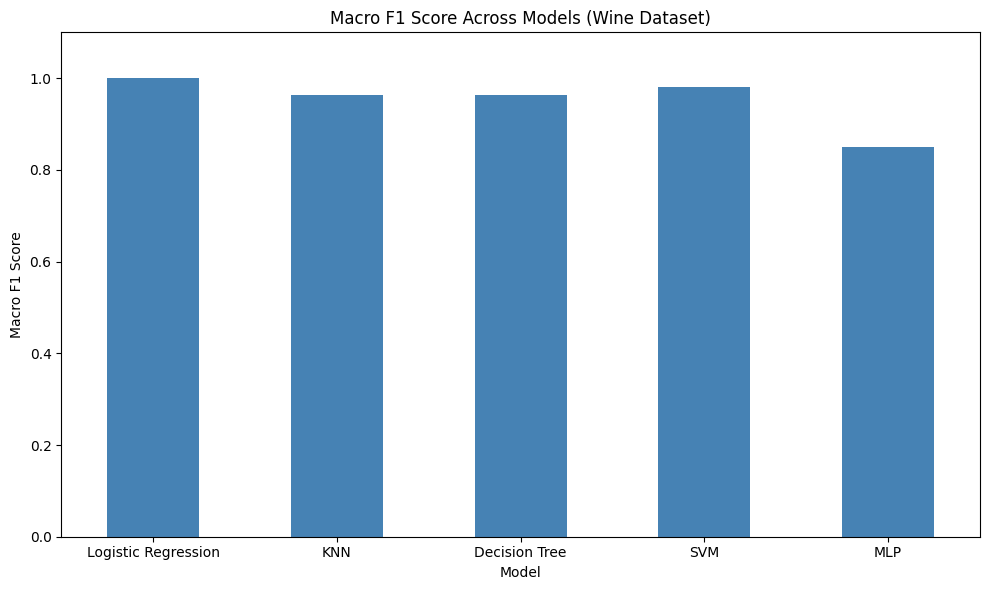

In [82]:
# Macro-F1 bar chart
### CODE HERE ###
# Macro-F1 bar chart
comparison_df_w['Macro F1'].plot(kind='bar', figsize=(10, 6), color='steelblue')

plt.title('Macro F1 Score Across Models (Wine Dataset)')
plt.xlabel('Model')
plt.ylabel('Macro F1 Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [83]:
# Cross-validation stability for all 5 wine models
### CODE HERE ###
# Cross-validation stability for all 5 wine models
models_w = {
    "Logistic Regression": best_lr_w,
    "KNN":                 best_knn_w,
    "Decision Tree":       best_dt_w,
    "SVM":                 best_svm_w,
    "MLP":                 best_mlp_w
}

for name, model in models_w.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_w_scaled, y_train_w, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f"{name}")
    print(f"  F1 Macro per fold: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f}  |  Std: {scores.std():.4f}\n")


Logistic Regression
  F1 Macro per fold: [0.9198 1.     1.     0.9602 1.    ]
  Mean: 0.9760  |  Std: 0.0321

KNN
  F1 Macro per fold: [0.9296 1.     0.9628 0.9213 1.    ]
  Mean: 0.9628  |  Std: 0.0334

Decision Tree
  F1 Macro per fold: [0.9214 0.8787 0.9628 0.844  0.8586]
  Mean: 0.8931  |  Std: 0.0435

SVM
  F1 Macro per fold: [1.     1.     1.     0.9602 1.    ]
  Mean: 0.9920  |  Std: 0.0159

MLP
  F1 Macro per fold: [0.7609 0.8382 0.7319 0.9602 0.9628]
  Mean: 0.8508  |  Std: 0.0969



### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [84]:
# Overfitting study: 3 Decision Tree variants
### CODE HERE ###
# Overfitting study: 3 Decision Tree variants
trees = {
    "Underfitting (max_depth=1)":   DecisionTreeClassifier(max_depth=1, random_state=42),
    "Overfitting (max_depth=None)": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Best Tuned Tree":              best_dt_w
}

for name, model in trees.items():
    model.fit(X_train_w_scaled, y_train_w)
    train_acc = accuracy_score(y_train_w, model.predict(X_train_w_scaled))
    test_acc  = accuracy_score(y_test_w,  model.predict(X_test_w_scaled))
    gap = train_acc - test_acc
    print(f"{name}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Gap:            {gap:.4f}\n")


Underfitting (max_depth=1)
  Train Accuracy: 0.6613
  Test Accuracy:  0.6111
  Gap:            0.0502

Overfitting (max_depth=None)
  Train Accuracy: 1.0000
  Test Accuracy:  0.9630
  Gap:            0.0370

Best Tuned Tree
  Train Accuracy: 0.9919
  Test Accuracy:  0.9630
  Gap:            0.0290



### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
